# Step 3: Make Your Classifier

In [1]:
from nn.nn import NeuralNetwork as nn
from nn.io import read_text_file, read_fasta_file
from nn.preprocess import sample_seqs, one_hot_encode_seqs

import numpy as np
import pandas as pd
from typing import List
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

np.random.seed(42)

read in files

In [2]:
pos = read_text_file('data/rap1-lieb-positives.txt')
neg = read_fasta_file('data/yeast-upstream-1k-negative.fa')

process

In [3]:
# get len pos
seq_len = len(pos[0])

# clip negs, based around center bc apparently that can be better for genomic data
def center_clip_seqs(seqs, length):
    clipped = []
    for s in seqs:
        if len(s) <= length:
            clipped.append(s)
        else:
            start = (len(s) - length) // 2
            clipped.append(s[start:start+length])
    return clipped

neg_clip = center_clip_seqs(neg, length = seq_len)

# combine, but as df for ease 
merged = pd.concat([pd.DataFrame({'seq': pos, 'label': True}), pd.DataFrame({'seq': neg_clip, 'label': False})])

In [4]:
merged

,seq,label
0,ACATCCGTGCACCTCCG,True
1,ACACCCAGACATCGGGC,True
2,CCACCCGTACCCATGAC,True
3,GCACCCATACATTACAT,True
4,ACATCCATACACCCTCT,True
...,...,...
3158,AGATGTGCCTTCACCAA,False
3159,TGAAGTAAAGGACACCA,False
3160,TTATGGAGCTTGTAAAT,False
3161,GTAATATTCACAAAACA,False


going to sample with nn.preprocess.py as built out

this method samples with replacement to equalize class counts. this upsamples the minority class to match the majority, so both classes have the same count, to try to preserve some class diversity while creating balanced mini-batches. this could lead to inflated model performance though, since it's likely that most of the pos sequences will be represented in the training set...

also interesting note from me. i was originally just going to clip and keep the first 17 bases, but then i wanted to do something **fancier** and asked chat what was a good way to clip... it said from center can be good for genomic data since maybe it'll preserve motifs? who knows.

In [5]:
sampled_seqs, sampled_labels = sample_seqs(merged['seq'], merged['label'])

one-hot encoding

In [6]:
onehot = one_hot_encode_seqs(sampled_seqs)

SPLIT!

In [7]:
# test
X_temp, X_test, y_temp, y_test = train_test_split(onehot, np.array(sampled_labels), test_size=0.2, random_state=42)
# train and val
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# 20:20:60 split
print('training', X_train.shape)
print('validation', X_val.shape)
print('test', X_test.shape)

training (3795, 68)
validation (1265, 68)
test (1266, 68)


nn here she comes

In [8]:
# use input size for input dim, duh
# cute easy numbers for other dims

architecture = [{'input_dim': 68, 'output_dim': 32, 'activation': 'relu'},
           {'input_dim': 32, 'output_dim': 16, 'activation': 'relu'},
           {'input_dim': 16, 'output_dim': 1, 'activation': 'sigmoid'}]

In [28]:
classifier = nn(architecture, lr = 0.00005, seed = 42, batch_size = 100, epochs = 300, loss_function = 'binary_cross_entropy')

In [29]:
train_losses, val_losses = classifier.fit(X_train, y_train, X_val, y_val)

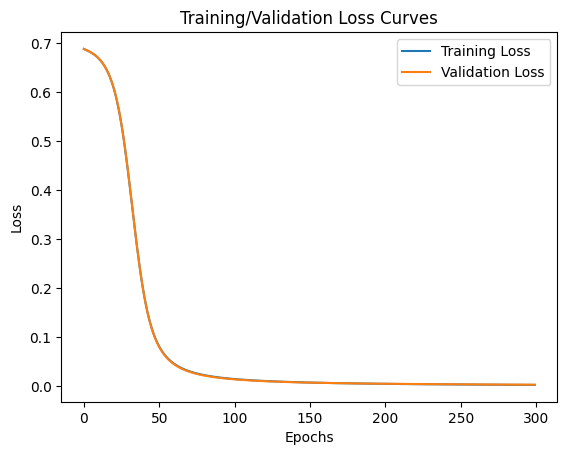

0.003220460785872526


In [30]:
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training/Validation Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(val_losses[-1]) # average validation loss

In [ ]:
y_hat = classifier.predict(X_val.T).T
accuracy = np.mean((y_hat > 0.5).flatten() == y_val)
print(f"accuracy: {accuracy}")

accuracy: 0.9992094861660079


### Hyperparam Explanation

in terms of architecture, the input dim had to be 6, and output 1 for binary classification. I chose 32 and 16 as the intermediate layer dims because they are nice numbers, but it seemed to work well! any wider/deeper might cause overfitting.

kept reLU in the hidden layers to help maintain gradients, but sigmoid in the output to get our classification [0,1].

Other hyperparams:
started with same lr, batch size, and # epochs as the autoencoder. ended up with accuracy = 1.0 and I was skeptical to say the least LOL...

So I checked out some other metrics for that model. avg reconstruction error was super high (0.5) and i have 141 overlapping samples in the training and validation set. it's not that much of an overlap compared to the full training/validation set? but i think that's definitely contributing to the results

500 epochs looked like more than enough as loss curves flattened and converged around 200/300 epochs, so I decreased. i also wanted to try a smaller learning rate-- 0.00005 looked pretty nice, and 300 epochs seemed like more than enough.

loss method is binary cross entropy as this is a binary classifier

some of the checks

In [21]:
reconstructed = (classifier.predict(X_val.T)).T
print(f'avg reconstruction error: {np.mean(np.square(X_val - reconstructed))}')

avg reconstruction error: 0.49976563440902294


In [17]:
train_set = set(map(tuple, X_train))
val_set = set(map(tuple, X_val))

overlap = train_set & val_set

print("Number of overlapping samples:", len(overlap))

Number of overlapping samples: 141


In [19]:
from sklearn.metrics import confusion_matrix, roc_auc_score

y_pred = (y_hat >= 0.5).astype(int)

print(confusion_matrix(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_hat))

[[633   0]
 [  0 632]]
ROC-AUC: 1.0
